In [41]:
# Data

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt

# time series 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Metrics 

from sklearn.metrics import mean_squared_error

In [42]:
df = pd.read_csv('data/air-passenger-traffic-per-month-port-authority-of-ny-nj-beginning-1977.csv')

df.head()

,Airport Code,Year,Month,Domestic Passengers,International Passengers,Total Passengers
0,ACY,2015,Jan,98177,90,98267
1,ACY,2015,Feb,96431,65,96496
2,ACY,2015,Mar,116493,197,116690
3,ACY,2015,Apr,105539,161,105700
4,ACY,2015,May,103668,425,104093


In [43]:
df.shape

(1584, 6)

In [44]:
df.isnull().sum()

Airport Code                0
Year                        0
Month                       0
Domestic Passengers         0
International Passengers    0
Total Passengers            0
dtype: int64

In [45]:
df.columns

Index(['Airport Code', 'Year', 'Month', 'Domestic Passengers',
       'International Passengers', 'Total Passengers'],
      dtype='object')

In [46]:
df['Airport Code'].unique()

array(['ACY', 'EWR', 'JFK', 'LGA', 'SWF'], dtype=object)

In [47]:
# jfk Filter 

df_jfk = df[df['Airport Code'] == 'JFK'].copy()

In [48]:
df['Month'].unique()

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'], dtype=object)

In this step, the categorical month values (e.g., "Jan", "Feb") are converted into numerical representations (1–12) to enable proper datetime construction.

This transformation is not considered label encoding for modeling purposes. Instead, it is a necessary preprocessing step to convert the dataset into a time series format.

After mapping the months to numerical values, a new datetime column is created by combining the year and month information. This allows us to set a proper time index, which is essential for time series analysis.

Finally, the datetime column is set as the index of the dataset to prepare it for further analysis.

In [49]:
# "Month Mapping and Datetime Construction"

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3,
    'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9,
    'Oct': 10, 'Nov': 11, 'Dec': 12
}

df_jfk['Month'] = df_jfk['Month'].map(month_map)

# Create a datetime column using Year and Month 

df_jfk['Date'] = pd.to_datetime(dict(
    year= df_jfk['Year'],
    month= df_jfk['Month'],
    day = 1 
))

# Set the datetime column as the index 

df_jfk.set_index('Date', inplace=True)

# Extract the time series (Target Variable)

ts = df_jfk['Total Passengers']

ts.head()

Date
2015-01-01    3952123
2015-02-01    3525008
2015-03-01    4417086
2015-04-01    4634132
2015-05-01    4965684
Name: Total Passengers, dtype: int64

In this step, a preliminary analysis of the dataset is performed to understand its structure and quality.

- The `info()` function provides information about data types and missing values.
- The `shape` attribute shows the number of observations and features.
- The `describe()` function summarizes the statistical properties of numerical variables such as mean, standard deviation, minimum, and maximum values.

This step ensures that the dataset is suitable for time series analysis and helps identify potential data quality issues.

In [50]:

df_jfk.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 468 entries, 2015-01-01 to 1977-12-01
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Airport Code              468 non-null    object
 1   Year                      468 non-null    int64 
 2   Month                     468 non-null    int64 
 3   Domestic Passengers       468 non-null    int64 
 4   International Passengers  468 non-null    int64 
 5   Total Passengers          468 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 25.6+ KB


In [51]:
df_jfk.shape


(468, 6)

In [52]:
df_jfk.describe()

,Year,Month,Domestic Passengers,International Passengers,Total Passengers
count,468.000000,468.000000,4.680000e+02,4.680000e+02,4.680000e+02
mean,1996.000000,6.500000,1.388556e+06,1.462530e+06,2.851086e+06
std,11.266672,3.455747,4.542171e+05,4.811367e+05,8.957019e+05
min,1977.000000,1.000000,7.220250e+05,5.156940e+05,1.237719e+06
25%,1986.000000,3.750000,1.032899e+06,1.115056e+06,2.139222e+06
50%,1996.000000,6.500000,1.203684e+06,1.391810e+06,2.604570e+06
75%,2006.000000,9.250000,1.759598e+06,1.751610e+06,3.418891e+06
max,2015.000000,12.000000,2.535971e+06,3.273753e+06,5.809724e+06


In [53]:
df_jfk.isnull().sum()

Airport Code                0
Year                        0
Month                       0
Domestic Passengers         0
International Passengers    0
Total Passengers            0
dtype: int64

In [54]:
df_jfk.dtypes

Airport Code                object
Year                         int64
Month                        int64
Domestic Passengers          int64
International Passengers     int64
Total Passengers             int64
dtype: object

In [55]:
df_jfk['Month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

### Time Series Visualization

The time series plot illustrates the monthly total number of passengers at JFK Airport over time.

From the graph, a clear upward trend can be observed, indicating that the number of passengers has generally increased over the years.

Additionally, recurring patterns can be seen within each year, suggesting the presence of seasonality. These seasonal fluctuations are typical in air transportation data, where passenger volumes tend to increase during certain periods such as summer and holiday seasons.

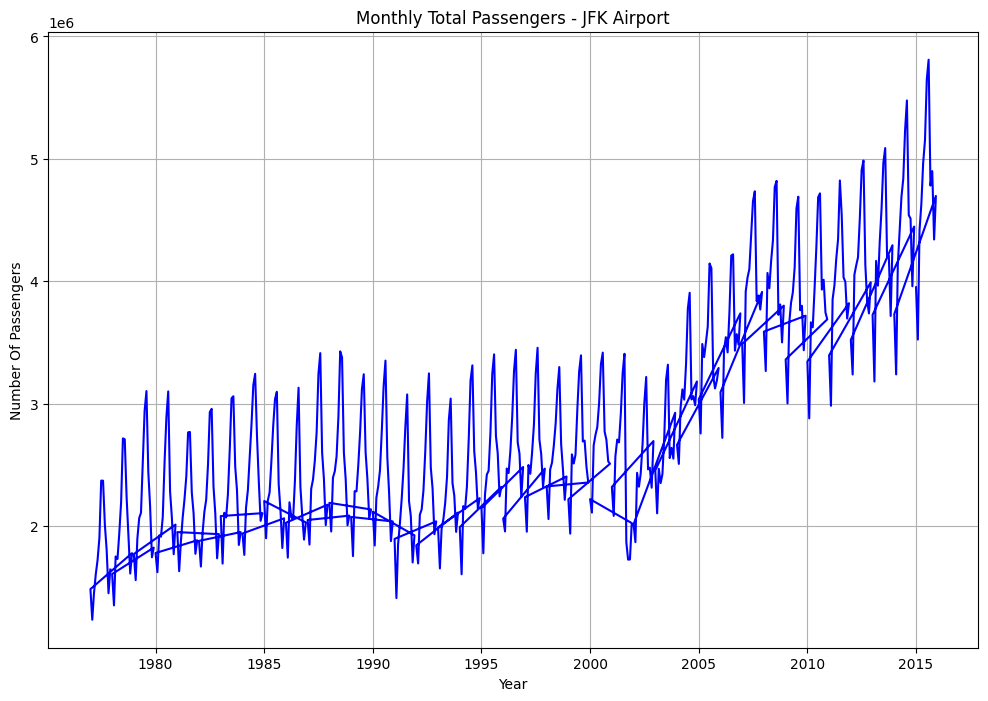

In [56]:
plt.figure(figsize=(12,8))
plt.plot(ts, color='blue')

plt.title('Monthly Total Passengers - JFK Airport')
plt.xlabel('Year')
plt.ylabel('Number Of Passengers')

plt.grid(True)
plt.show()

In [61]:
df_jfk['month_name'] = df_jfk.index.month

In [62]:
df_jfk.columns

Index(['Airport Code', 'Year', 'Month', 'Domestic Passengers',
       'International Passengers', 'Total Passengers', 'month_name'],
      dtype='object')

<Figure size 1000x800 with 0 Axes>

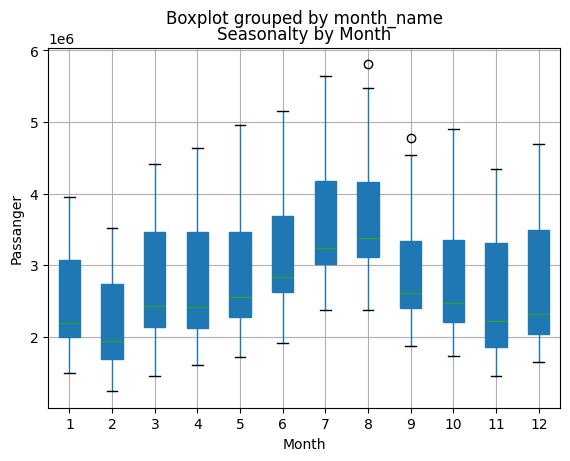

In [66]:
plt.figure(figsize=(10,8))
df_jfk.boxplot(
    column='Total Passengers',
    by='month_name',
    patch_artist=True
    )

plt.title('Seasonalty by Month')
plt.xlabel('Month')
plt.ylabel('Passanger')
plt.show()

### Yearly Trend Analysis

To better understand the long-term trend in the data, the time series was resampled on a yearly basis by calculating the average number of passengers for each year.

This approach helps reduce short-term fluctuations and makes the overall trend more visible.

From the resulting plot, a clear upward trend can be observed, indicating a steady increase in passenger traffic over time. This confirms the presence of a strong trend component in the dataset.

C:\Users\Merve\AppData\Local\Temp\ipykernel_5756\3047899165.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = ts.resample('Y').mean()


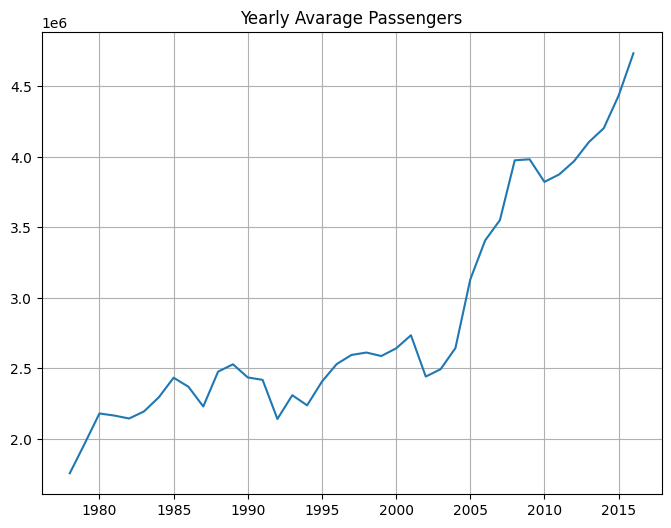

In [72]:
yearly = ts.resample('Y').mean()

plt.figure(figsize=(8, 6))
plt.plot(yearly)

plt.title('Yearly Avarage Passengers')
plt.grid(True)
plt.show()

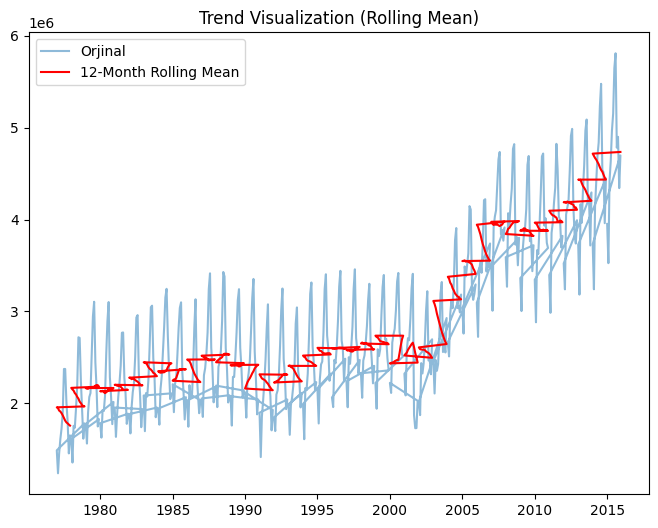

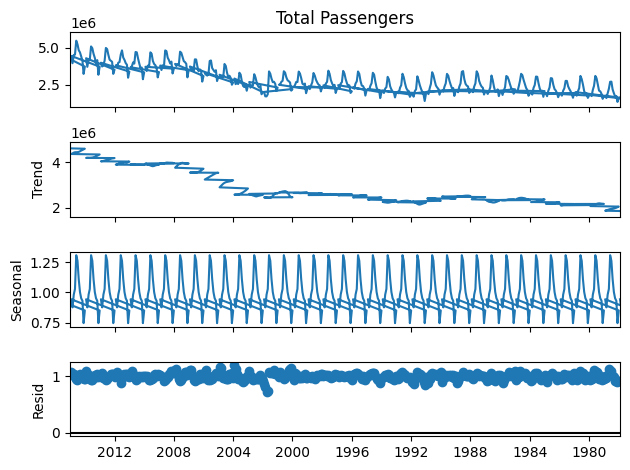

In [74]:
rolling = ts.rolling(window=12).mean()

plt.figure(figsize=(8,6))
plt.plot(ts, alpha=0.5, label='Orjinal')
plt.plot(rolling, color='red', label='12-Month Rolling Mean')

plt.legend()
plt.title("Trend Visualization (Rolling Mean)")
plt.show()

result = seasonal_decompose(ts, model='multiplicative', period=12)
result.plot()
plt.show()

### Time Series Decomposition Analysis

The time series was decomposed into its main components: trend, seasonality, and residuals.

- **Trend Component:**  
  The trend shows a general downward movement in earlier years, followed by a stabilization and slight increase in later periods. This indicates that passenger traffic experienced structural changes over time.

- **Seasonal Component:**  
  A strong and consistent seasonal pattern is observed. Passenger numbers follow a repeating cycle every year, with clear peaks and troughs. This confirms that seasonality is a dominant characteristic of the dataset.

- **Residual Component:**  
  The residuals appear to be randomly distributed around a constant level, suggesting that most of the systematic patterns in the data have been successfully captured by the trend and seasonal components.

Overall, the decomposition confirms that the dataset contains both significant trend and strong seasonal effects, making it suitable for time series forecasting models that account for both components.